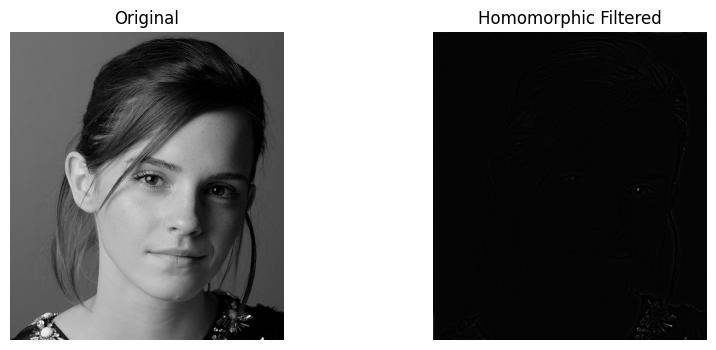

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -------- Load Image --------
img = cv2.imread('emma.jpg', cv2.IMREAD_GRAYSCALE)

# Convert to float (avoid log(0))
img = img.astype(np.float32) + 1

# -------- Step 1: Log Transform --------
log_img = np.log(img)

# -------- Step 2: Fourier Transform --------
dft = np.fft.fft2(log_img)
dft_shift = np.fft.fftshift(dft)

# -------- Step 3: Create High-Pass Filter (FIXED) --------
rows, cols = img.shape
crow, ccol = rows // 2, cols // 2

sigma = 30

# Correct meshgrid (IMPORTANT FIX)
x = np.arange(cols)
y = np.arange(rows)
X, Y = np.meshgrid(x, y)

# Distance from center
D2 = (X - ccol)**2 + (Y - crow)**2

# Gaussian High-pass filter
H = 1 - np.exp(-D2 / (2 * sigma**2))

# -------- Step 4: Apply Filter --------
filtered = dft_shift * H

# -------- Step 5: Inverse Fourier --------
inv_shift = np.fft.ifftshift(filtered)
inv_img = np.fft.ifft2(inv_shift)
inv_img = np.real(inv_img)

# -------- Step 6: Exponential --------
exp_img = np.exp(inv_img)

# -------- Step 7: Normalize --------
result = cv2.normalize(exp_img, None, 0, 255, cv2.NORM_MINMAX)
result = result.astype(np.uint8)

# -------- Display --------
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(result, cmap='gray')
plt.title("Homomorphic Filtered")
plt.axis('off')

plt.show()